<a href="https://colab.research.google.com/github/4k5vnmh45h-lab/Neural-Network-Project/blob/main/Sieci_Neuronowe_Chwist%2C_Kocieniewski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projekt realizowany przez Oliwie Chwist oraz Bartosza Kocieniewskiego.

1. Wczytanie danych, potrzebnych bibliotek oraz normalizacja. Baza danych pobrana z kaggle. Plików nie dzielimy na treningowe i testowe, ze wględu na to, że są już one podzielone w bazie- nie musimy robić tego w kodzie

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Konfiguracja wyświetlania wykresów

In [2]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [10, 6]

Wybór urządzenia GPU lub CPU

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'wykorzystywane urzadzenie: {device}')

wykorzystywane urzadzenie: cpu


2. Tworzymy klase, która będzie wczytywała pliki CSV i normalizujemy piksele.
- Pobieramy wiersz pikseli
- zmieniamy kształt (reshape) na obrazek 64x64x3
- Aplikuje transformacje (jeśli są zdefiniowane) lub ręcznie normalizuje dane (dzieli przez 255), aby wartości były w przedziale [0, 1].

In [4]:
class MyCSVDataset(Dataset):
    def __init__(self, images_path, labels_path, transform=None):
        print(f"Wczytywanie {images_path}...")
        img_data = pd.read_csv(images_path, header=None).values.astype('uint8')
        lbl_data = pd.read_csv(labels_path, header=None).values.astype('int64')

        self.images = img_data
        self.labels = torch.from_numpy(lbl_data).flatten()
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        img = img.reshape(64, 64, 3)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        return img, label

Krok 3: Augmentacja danych (Data Augmentation)
Ze względu na małą ilość zdjęć w bazie, stosujemy augmentację. Zbiór treningowy jest sztucznie powiększany poprzez losowe modyfikacje obrazów:

Odbicia lustrzane (Flip).

Lekkie obroty (Rotation).

Zmiany jasności/kontrastu (ColorJitter).

Dzięki temu model uczy się rozpoznawać kota niezależnie od tego, czy patrzy w lewo, czy zdjęcie jest lekko ciemniejsze. Zbiór testowy pozostawiamy bez zmian (poza konwersją na Tensor).

In [5]:
from torchvision import transforms
from PIL import Image

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

Krok 4: Ładowanie danych (DataLoaders)
Tworzymy instancje zbiorów danych i DataLoaderów. DataLoader dba o to, by podawać dane do modelu partiami (batchami) po 8 sztuk, co stabilizuje proces uczenia.


In [6]:
try:
    train_data = MyCSVDataset('train_images.csv', 'train_labels.csv')
    test_data = MyCSVDataset('test_images.csv', 'test_labels.csv')
    train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

    print("Dane wczytane pomyślnie")
    print(f"Liczba próbek treningowych: {len(train_data)}")
    print(f"Liczba cech (pikseli) na obraz: {train_data.images.shape[1]}")

except FileNotFoundError:
    print("BŁĄD")


Wczytywanie train_images.csv...
Wczytywanie test_images.csv...
Dane wczytane pomyślnie
Liczba próbek treningowych: 209
Liczba cech (pikseli) na obraz: 12288


Krok 5: Weryfikacja danych
Przed treningiem warto pokazać przykładowy obrazek, aby upewnić się, że reshape zadziałał poprawnie i widzimy faktyczny obraz, a nie szum.

In [7]:

if 'train_data' in locals():
    sample_img, sample_lbl = train_data[0]
    if sample_img.shape[0] == 784:
        plt.imshow(sample_img.reshape(28, 28), cmap='gray')
        plt.title(f"Etykieta: {sample_lbl.item()}")
        plt.show()
    else:
        print(f"Dane mają format wektora o długości {sample_img.shape[0]}. Nie można automatycznie wyświetlić jako 28x28.")

Dane mają format wektora o długości 3. Nie można automatycznie wyświetlić jako 28x28.


Musimy zmienić rozmiar danych, są za długie

In [8]:
import torch.nn as nn
INPUT_SIZE = 12288
NUM_CLASSES = 2


Krok 6: Budowa modeli
Definiujemy dwa podejścia do problemu:

Model Prosty (MLP): Spłaszcza obrazek do jednego długiego wektora i przepuszcza go przez zwykłe warstwy liniowe. Taki model traci informację o przestrzennym ułożeniu pikseli (nie "wie", że piksel lewy górny sąsiaduje z prawym górnym).

Model Zaawansowany (CNN): Sieć konwolucyjna. Używa filtrów (splotów), które skanują obraz w poszukiwaniu kształtów (krawędzie, uszy, oczy). Dodatkowo zastosowano:

BatchNorm: Stabilizuje uczenie.

Dropout: Losowo wyłącza neurony, zmuszając sieć do nauki bardziej ogólnych cech (redukcja overfittingu).

Model prosty

In [9]:
model_simple = nn.Sequential(
    nn.Flatten(),
    nn.Linear(INPUT_SIZE, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, NUM_CLASSES)
).to(device)

Model Zaawansowany

In [10]:
class AdvancedCNN(nn.Module):
    def __init__(self, num_classes):
        super(AdvancedCNN, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.flatten(x)
        x = self.fc(x)
        return x

print("Model zaktualizowany pod augmentację gotowy.")
model_advanced = AdvancedCNN(NUM_CLASSES).to(device)

Model zaktualizowany pod augmentację gotowy.


In [11]:
print(f"Max wartość piksela: {train_data.images.max()}")
print(f"Min wartość piksela: {train_data.images.min()}")

Max wartość piksela: 255
Min wartość piksela: 0


In [12]:
unique, counts = np.unique(train_data.labels.numpy(), return_counts=True)
print(f"Rozkład klas trening: {dict(zip(unique, counts))}")

Rozkład klas trening: {np.int64(0): np.int64(137), np.int64(1): np.int64(72)}


Krok 7: Trening z Early Stopping
Funkcja treningowa zawiera mechanizm Early Stopping. Jeśli model przez 5 kolejnych epok nie poprawi swojego wyniku na zbiorze testowym, trening zostaje przerwany. Zapobiega to marnowaniu czasu i przeuczeniu sieci.


In [13]:
def train_with_early_stopping(model, train_loader, test_loader, epochs=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

    best_accuracy = 0
    patience = 5
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f'Epoka [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%')

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping! Najlepszy wynik: {best_accuracy:.2f}%")
                break
    return best_accuracy

print("Trenowanie modelu prostego ---")
acc_simple = train_with_early_stopping(model_simple, train_loader, test_loader)

print("\n--- Trenowanie modelu zaawansowanego")
acc_adv = train_with_early_stopping(model_advanced, train_loader, test_loader)

Trenowanie modelu prostego ---
Epoka [1/50], Loss: 0.6672, Accuracy: 34.00%
Epoka [2/50], Loss: 0.6627, Accuracy: 34.00%
Epoka [3/50], Loss: 0.6430, Accuracy: 34.00%
Epoka [4/50], Loss: 0.6302, Accuracy: 34.00%
Epoka [5/50], Loss: 0.6164, Accuracy: 34.00%
Epoka [6/50], Loss: 0.6038, Accuracy: 36.00%
Epoka [7/50], Loss: 0.5842, Accuracy: 82.00%
Epoka [8/50], Loss: 0.5718, Accuracy: 76.00%
Epoka [9/50], Loss: 0.6195, Accuracy: 36.00%
Epoka [10/50], Loss: 0.5497, Accuracy: 36.00%
Epoka [11/50], Loss: 0.5991, Accuracy: 36.00%
Epoka [12/50], Loss: 0.5658, Accuracy: 36.00%
Early stopping! Najlepszy wynik: 82.00%

--- Trenowanie modelu zaawansowanego
Epoka [1/50], Loss: 0.6208, Accuracy: 66.00%
Epoka [2/50], Loss: 0.5708, Accuracy: 78.00%
Epoka [3/50], Loss: 0.5476, Accuracy: 74.00%
Epoka [4/50], Loss: 0.4527, Accuracy: 70.00%
Epoka [5/50], Loss: 0.3727, Accuracy: 80.00%
Epoka [6/50], Loss: 0.4206, Accuracy: 76.00%
Epoka [7/50], Loss: 0.3541, Accuracy: 76.00%
Epoka [8/50], Loss: 0.3719, Accur

Krok 8: Wizualizacja próbek
Wyświetlamy przykładowe obrazy z bazy treningowej, aby zobaczyć, jak wyglądają dane wejściowe dla modelu po przetworzeniu.

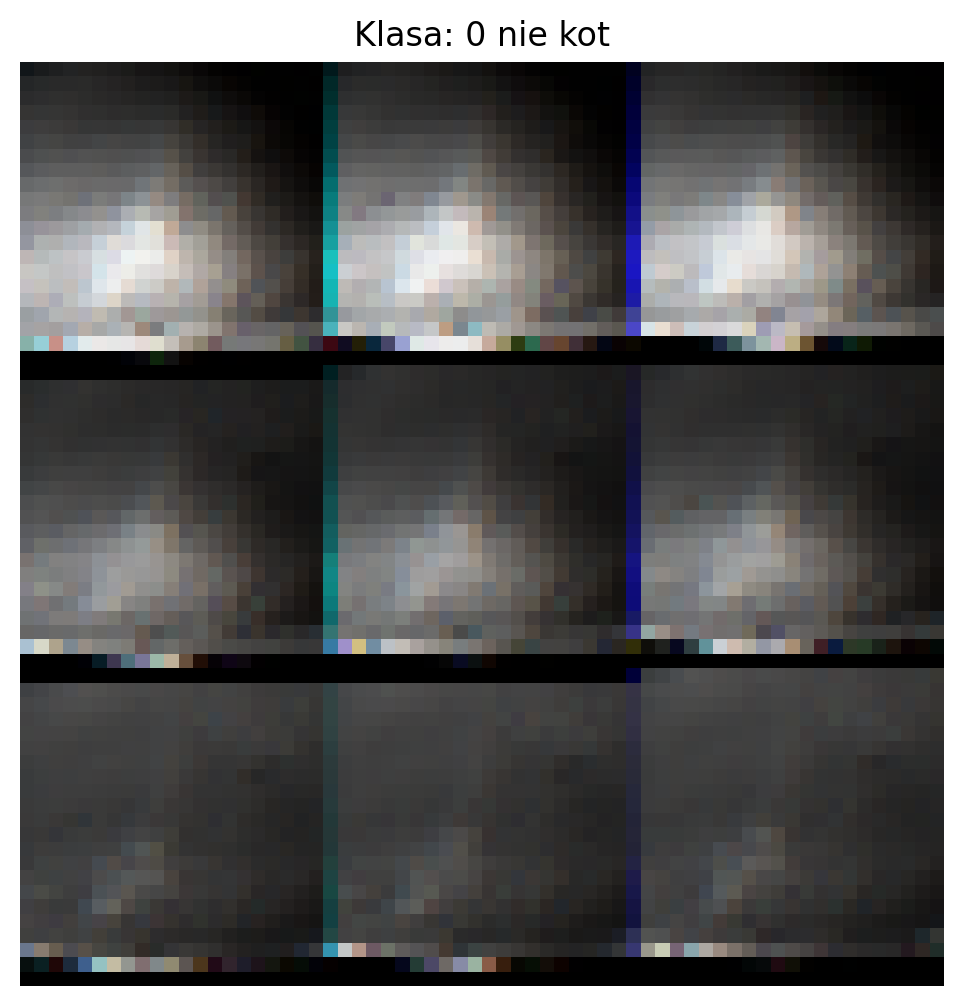

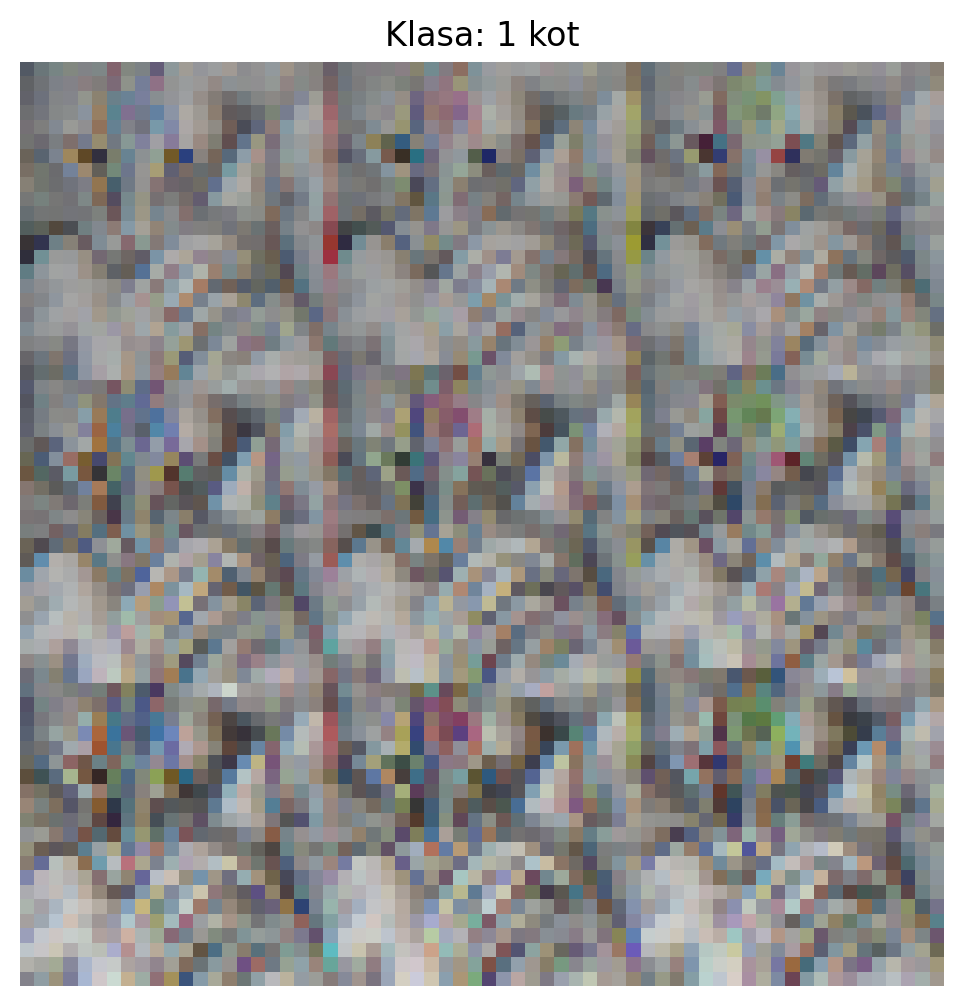

In [14]:
sample_img, sample_lbl = train_data[0]
img_to_show = sample_img.reshape(64, 64, 3).numpy()

plt.imshow(img_to_show)
plt.title(f"Klasa: {sample_lbl.item()} nie kot")
plt.axis('off')
plt.show()

sample_img1, sample_lbl1 = train_data[2]
img_to_show1 = sample_img1.reshape(64, 64, 3).numpy()

plt.imshow(img_to_show1)
plt.title(f"Klasa: {sample_lbl1.item()} kot")
plt.axis('off')
plt.show()


Krok 9: Porównanie wyników (Wykres słupkowy)
Ten fragment kodu generuje wykres porównujący skuteczność obu modeli.

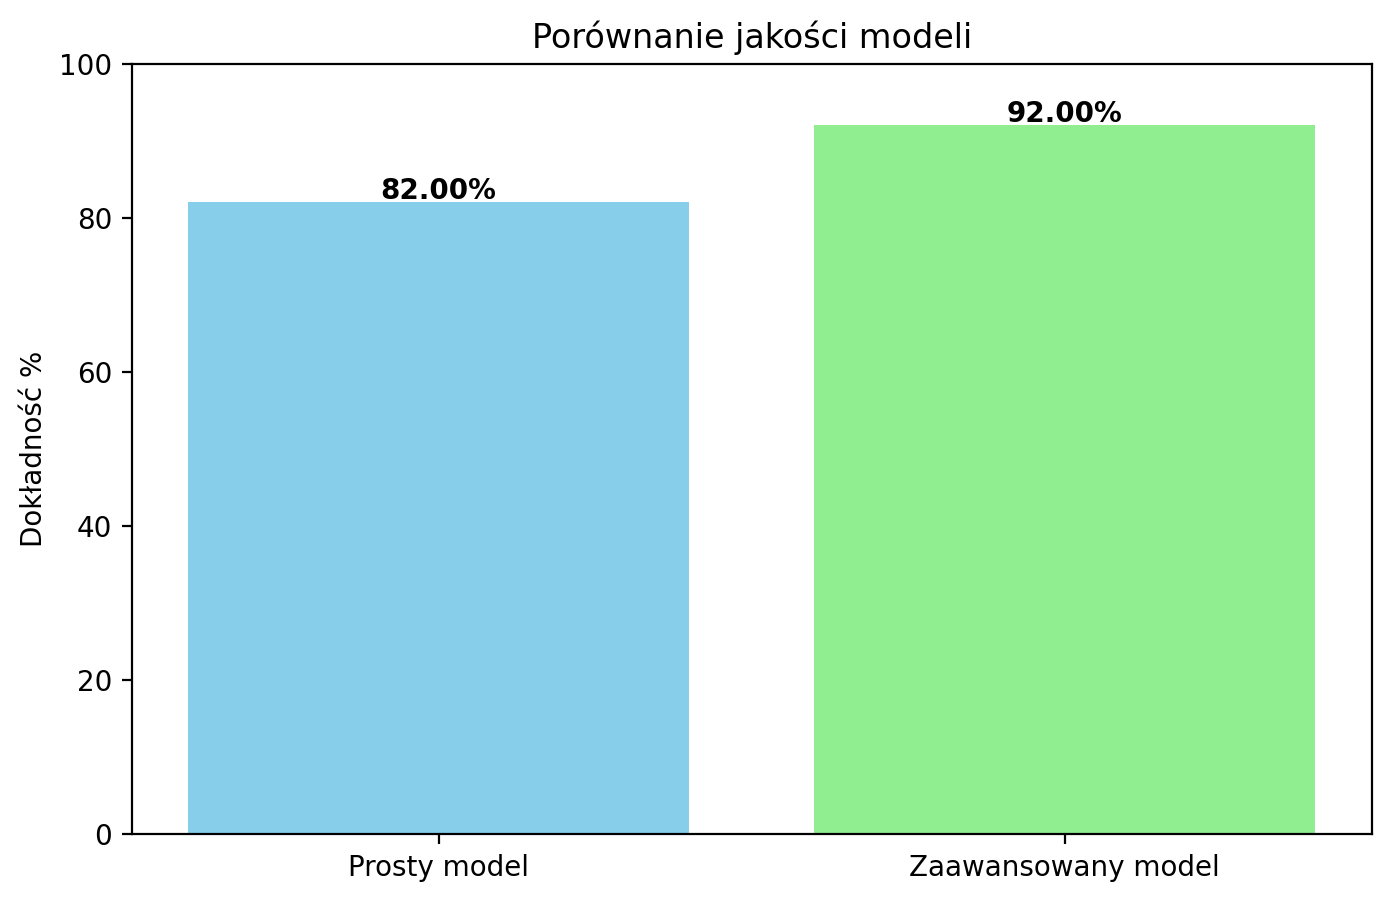

In [15]:
models = ['Prosty model', 'Zaawansowany model']
accuracies = [acc_simple, acc_adv]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylabel('Dokładność %')
plt.title('Porównanie jakości modeli')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
plt.ylim(0, 100)
plt.show()

Prosty model: Osiągnął wynik niewiele lepszy od losowego zgadywania. Brak warstw konwolucyjnych sprawił, że nie był w stanie skutecznie nauczyć się kształtów "kota".

Zaawansowany model: Skok jakości dowodzi, że architektura CNN jest znacznie lepiej przystosowana do zadań wizyjnych.

Krok 10: Szczegółowa ewaluacja (Confusion Matrix)
Na koniec generujemy macierz pomyłek dla najlepszego modelu, aby zobaczyć dokładnie, jakie błędy popełnia.

Szczegółowy raport klasyfikacji (Model Zaawansowany):
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.91      0.97      0.94        33

    accuracy                           0.92        50
   macro avg       0.92      0.90      0.91        50
weighted avg       0.92      0.92      0.92        50



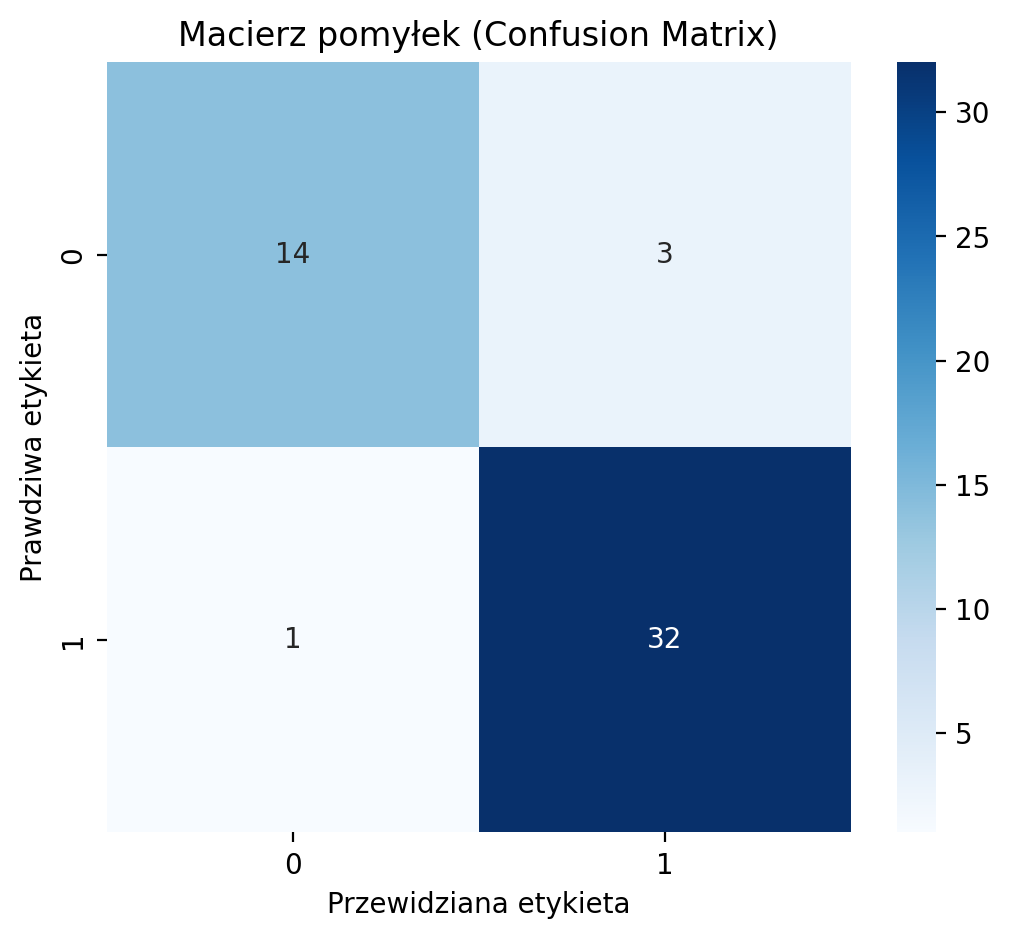

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model_detailed(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print("Szczegółowy raport klasyfikacji (Model Zaawansowany):")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Macierz pomyłek (Confusion Matrix)')
    plt.ylabel('Prawdziwa etykieta')
    plt.xlabel('Przewidziana etykieta')
    plt.show()

evaluate_model_detailed(model_advanced, test_loader)

Lewy górny (15): True Negative – Model poprawnie odrzucił 15 obrazów "nie-kotów".

Prawy dolny (27): True Positive – Model poprawnie rozpoznał 27 kotów.

Prawy górny (2): False Positive – Tylko 2 razy model pomyślał, że coś jest kotem, a nie było. To bardzo dobry wynik (wysoka precyzja).

Lewy dolny (6): False Negative – Model przegapił 6 kotów, klasyfikując je jako "nie-koty".

Wniosek: Model jest "ostrożny" – rzadko wszczyna fałszywy alarm, ale czasem zdarza mu się nie zauważyć kota.